In [31]:
import sys
import os

# Adds the parent directory to sys.path
sys.path.append("..")

from utils.data_utils import create_test_data, create_multi_modal_test_data
from utils.plotting_utils import create_multi_fig_with_stats
from utils.modelling_utils import identify_multi_modes_in_dataset, identify_anomalies_in_multimodal_data

Create faux data for various distributions and plot all distributions on the same figure with stats: median, mean, and upper and lower three sigma thresholds.

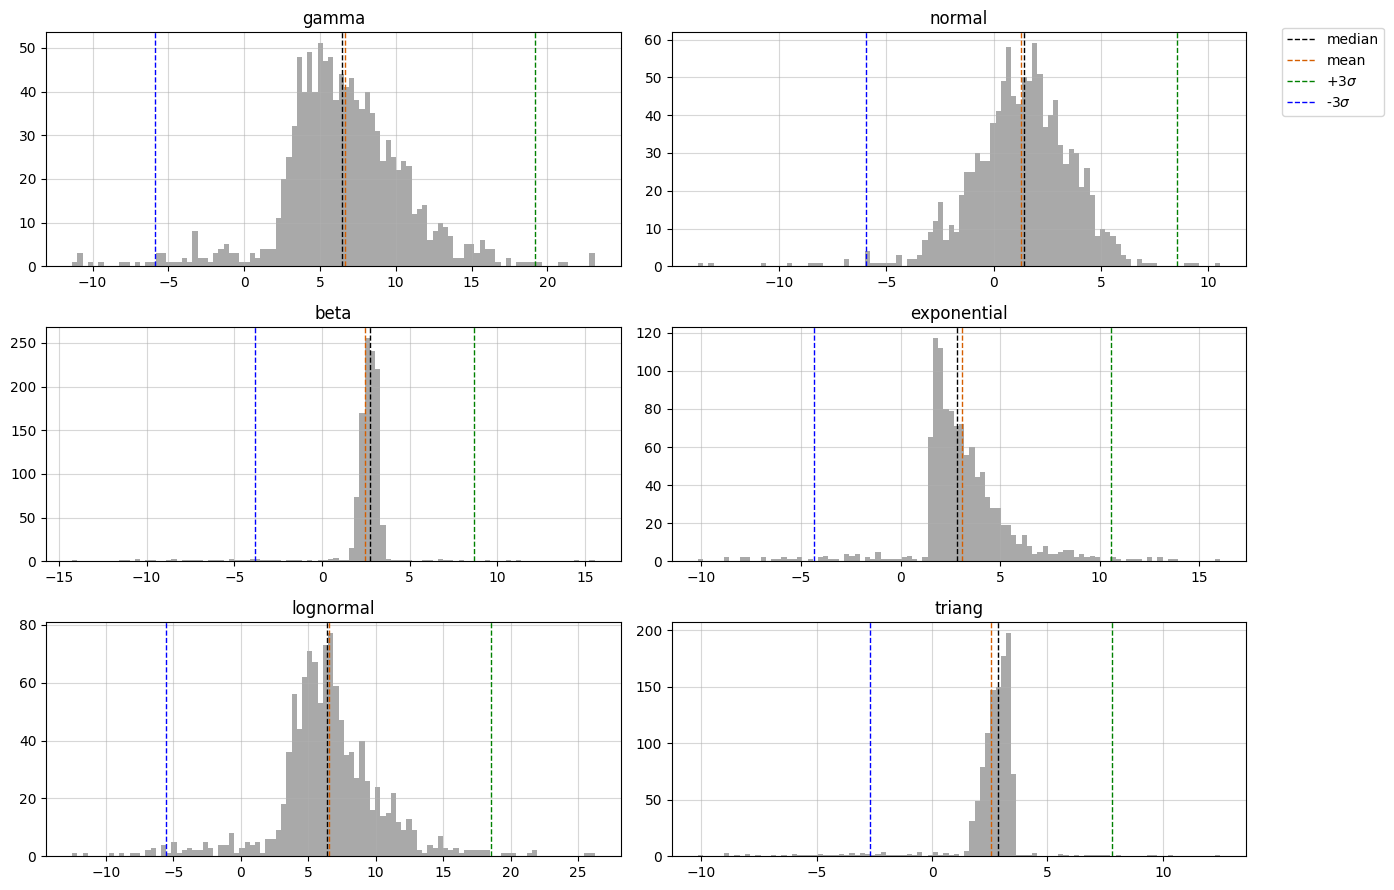

In [32]:
test_data = create_test_data(noise_std=5.0, noise_size=100)
fig1 = create_multi_fig_with_stats(input_data=test_data, plot_type="hist")

Generate and plot a multi-modal dataset.

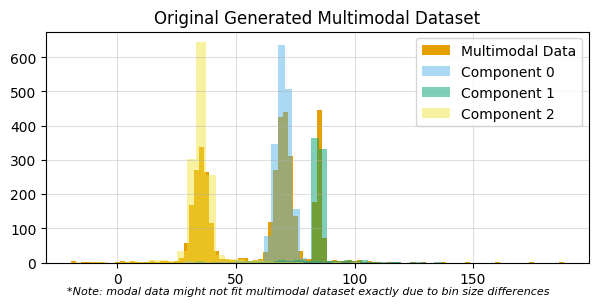

In [33]:
multimodal_data, modes, fig2 = create_multi_modal_test_data(
    loc_range=(0, 100),
    std_range=(1, 5),
    size_range=(500, 2000),
    n_modes=3,
    noise_std=20.0,
    noise_size=100,
    show_fig=True
    )

Fit a Gaussian Mixture Model to the generated multi-modal dataset, extract the modes, apply 3-sigma thresholds to each mode. Plot all findings.

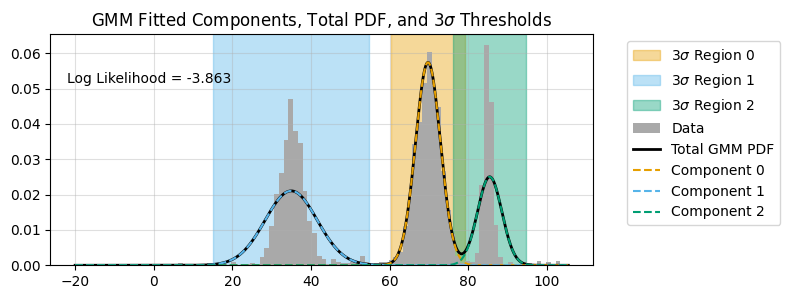

In [34]:
gmm_results, best_fit_component, upper, lower, fig3 = identify_multi_modes_in_dataset(
        multimodal_data,
        min_scrub=0.05,
        max_scrub=99.5,
        max_components=5,
        max_iter=1000,
        show_fig=True
)

Using calculated thresholds, identify statistical anomalies within the multi-modal dataset.

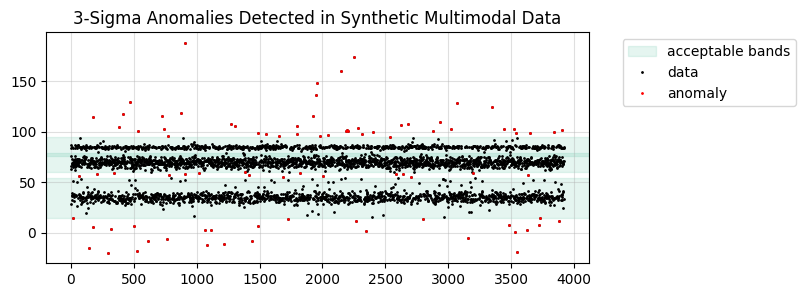

{'thresholds': [(60.3, 79.304), (15.046, 54.879), (76.23, 94.784)],
 'n_anomalies': 87,
 'anomaly_ratio': 0.022,
 'anomalies': [{'date': 16, 'value': 14.603},
  {'date': 69, 'value': 56.399},
  {'date': 143, 'value': -15.05},
  {'date': 175, 'value': 115.269},
  {'date': 177, 'value': 6.261},
  {'date': 205, 'value': 58.725},
  {'date': 297, 'value': -19.673},
  {'date': 317, 'value': 4.134},
  {'date': 341, 'value': 59.757},
  {'date': 387, 'value': 104.781},
  {'date': 418, 'value': 117.821},
  {'date': 471, 'value': 129.349},
  {'date': 502, 'value': 6.572},
  {'date': 526, 'value': -18.056},
  {'date': 534, 'value': 100.891},
  {'date': 615, 'value': -7.923},
  {'date': 728, 'value': 115.426},
  {'date': 737, 'value': 102.518},
  {'date': 768, 'value': -6.167},
  {'date': 775, 'value': 95.493},
  {'date': 781, 'value': 57.829},
  {'date': 875, 'value': 119.151},
  {'date': 905, 'value': 58.361},
  {'date': 906, 'value': 188.308},
  {'date': 1021, 'value': 59.558},
  {'date': 1066, 

In [35]:
output, fig = identify_anomalies_in_multimodal_data(multimodal_data, lower, upper)
output

In [36]:
gmm_results

{1: {'means': array([60.64627058]),
  'covariances': array([411.0274594]),
  'weights': array([1.]),
  'bic': 34539.31791922442,
  'pdf_total': array([7.13263063e-06, 7.31072405e-06, 7.49297618e-06, 7.67947650e-06,
         7.87031624e-06, 8.06558837e-06, 8.26538767e-06, 8.46981073e-06,
         8.67895600e-06, 8.89292379e-06, 9.11181635e-06, 9.33573787e-06,
         9.56479449e-06, 9.79909439e-06, 1.00387478e-05, 1.02838669e-05,
         1.05345661e-05, 1.07909620e-05, 1.10531733e-05, 1.13213208e-05,
         1.15955277e-05, 1.18759194e-05, 1.21626237e-05, 1.24557706e-05,
         1.27554926e-05, 1.30619247e-05, 1.33752040e-05, 1.36954706e-05,
         1.40228668e-05, 1.43575375e-05, 1.46996304e-05, 1.50492956e-05,
         1.54066861e-05, 1.57719575e-05, 1.61452683e-05, 1.65267797e-05,
         1.69166558e-05, 1.73150636e-05, 1.77221731e-05, 1.81381571e-05,
         1.85631916e-05, 1.89974556e-05, 1.94411313e-05, 1.98944040e-05,
         2.03574621e-05, 2.08304974e-05, 2.13137049e-05